The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 0 with train loss: 0.2377339384063732 and eval loss: 0.35405779474725324
Epoch 1 with train loss: 0.08761756208746932 and eval loss: 0.3298856442173322
Epoch 2 with train loss: 0.08340375008451384 and eval loss: 0.33372742341210443
Epoch 3 with train loss: 0.0819946500624335 and eval loss: 0.28203059795002144
Epoch 4 with train loss: 0.08084452182574328 and eval loss: 0.3021272647505005
Epoch 5 with train loss: 0.08025390031032784 and eval loss: 0.2737916012605031
Epoch 6 with train loss: 0.07930982199519179 and eval loss: 0.3207472572103143
Epoch 7 with train loss: 0.0786804458949455 and eval loss: 0.27564543516685563
Epoch 8 with train loss: 0.07887969183367352 and eval loss: 0.2755707800388336
Epoch 9 with train loss: 0.07825981795268003 and eval loss: 0.30457891958455247
Epoch 10 with train loss: 0.0772476113552964 and eval loss: 0.28697800387938815
Epoch 11 with train loss: 0.077038851544

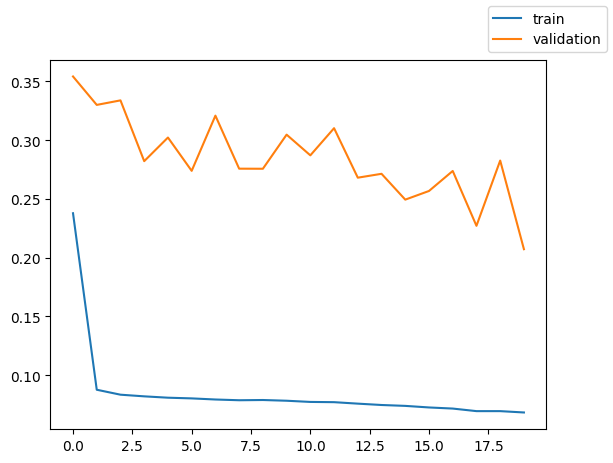

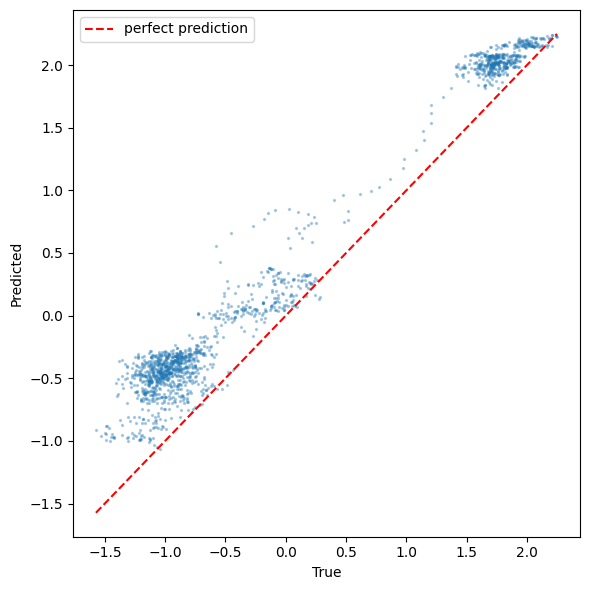

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pickle

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup

df = pd.read_csv('../data/CESMDataset_Try.csv')

target_col = 'PD_200m'
feature_cols = ['SFWF', 'AMOC']
lag = 50
horizon = 1
n = len(df)
train_end = int(n * 0.7)
test_end = int(n * 0.9)
batch_size = 128

X_train_lag, y_train_lag, X_test_lag, y_test_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(df, 
                                                                                                                 target_col, 
                                                                                                                 feature_cols,
                                                                                                                 train_end,
                                                                                                                 test_end,
                                                                                                                 lag,
                                                                                                                 horizon)

X_train_t, y_train_t, train_loader, X_test_t, y_test_t, test_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(batch_size, 
                                                                                                                          X_train_lag, 
                                                                                                                          y_train_lag, 
                                                                                                                          X_test_lag, 
                                                                                                                          y_test_lag, 
                                                                                                                          X_eval_lag, 
                                                                                                                          y_eval_lag)
device = "cpu"
n_epochs = 20

params = {
    'n_features': len(feature_cols),
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': nn.MSELoss()
}

NN_PD_200m, train_losses, eval_losses = model_setup(device, params, n_epochs, train_loader, eval_loader, X_eval_t, y_eval_lag)

torch.save({
    'state_dict': NN_PD_200m.state_dict(),
    'config': {
        'n_features': len(feature_cols),
        'hidden_size': 64,
        'num_layers': 1,
        'dropout': 0.0,
    },
}, 'PD_200m_model.pth')

with open('scalers_PD_200m.pkl', 'wb') as f:
    pickle.dump({'y_scaler': y_scaler, 'x_scaler': x_scaler}, f)